# AE for representation learning with simulated data

As seen in the introductory document, **AEs** are able to map input to a lower dimensional representation, it is in this regard an unsupervised dimensionality reduction technique, just as **principal component analysis** (PCA). Actually, when an AE has a one-layer encoder, its model is pretty close to that of **PCA** which also minimizes **MSE**. 

In this exercise, we will illustrate the ability of **AEs** to perform dimensionality reduction on a toy dataset. 
Unlike the previous practical, we will not instantiate directly a layer. Instead we will use instances of `torch.Parameter` for the weight matrices ${\mathbf{w}^{(j)}}$ and intercept vectors ${\mathbf{b}^{(j)}}$. The goal is twofold:
 - It shows you that `torch` is quite flexible and that customized layers are not difficult to create,
 - We will be easily able to tie matrices as discussed in the introductory document.

From these variables, we can complete the computation graph by using `torch` calculus functions.

Let us create a first rudimentary **AE** and train it to learn a 2D representation from the following 3D dataset:

<img src="dataset.png" alt="3D dataset" width="400"/>

To complete the exercise, you must fill the gaps in the blocks bellow. 

In these blocks, you will see:
 - a first cell that creates a synthetic dataset where inputs are in 3D,
 - a second cell where a new python class **Basic_AE** is defined,
 - a third cell where an instance of this class is created,
 - a fourth cell, where the model instance is trained,
 - and a final and fifth cell where we visualize results.


**Remark** In these practicals, we will use the exponential linear unit (**ELU**) activation function which approximates **ReLU**, but provides also negative values as activations.

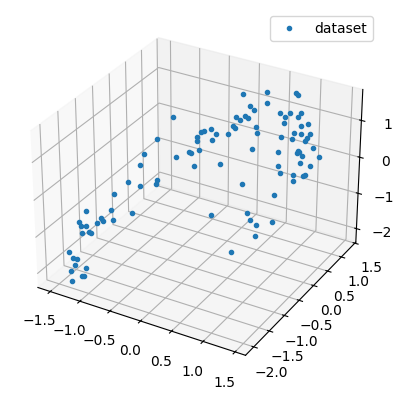

In [54]:
import torch as tf
from sklearn.preprocessing import StandardScaler
import numpy.random as rnd
import numpy as np
import os
import matplotlib.pyplot as plt

rep = "."


#%%
####################
#Dataset generation#
####################

rnd.seed(4)
m = 200
w1, w2 = 0.1, 0.3
noise = 0.1

angles = rnd.rand(m) * 3 * np.pi / 2 - 0.5
data = np.empty((m, 3))
data[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * rnd.randn(m) / 2
data[:, 1] = np.sin(angles) * 0.7 + noise * rnd.randn(m) / 2
data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * rnd.randn(m)

scaler = StandardScaler()
X_train = scaler.fit_transform(data[:100]).astype('float32')
X_test = scaler.transform(data[100:]).astype('float32')

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(X_train[:,0], X_train[:,1], X_train[:,2],'.', label='dataset')
ax.legend()
plt.show()

In the block bellow `Basic_AE` class is a child class of `torch.nn.Module` which defines a framework for designing a customized `torch` models. The constructor of the class is already partially written. This constructor is meant to create instances of `torch.nn.Parameters` with appropriate sizes. 

### Q1

Assuming that we build an AE whose **decoder and encoder have only one layer**, fill the gaps in the constructor definition. 
The missing numbers are integers that are elements of the list `unit_nbrs` which contains the input dimension followed by the desired number of units per layer. In this exercise, we thus have `len(unit_nbrs)=2`.

There are also missing instructions in the `Basic_AE.__call__` function. This function will allow an instance of the class to be also a callable object, because neural networks are functions mapping inputs to predictions. In this case the **AE** is meant to map $\mathbf{x}$ to $\tilde{\mathbf{x}}$. Fill the gaps in `Basic_AE.__call__` by using `torch` ops such as `tf.matmul` and `tf.transpose`.

In [108]:
###############################################
#Dimensionality reduction with an auto-encoder#
###############################################

d_in = 3 #input dimensionality
d_hid = 2 #code dimensionality
d_out = d_in #output dimensionality

activation = torch.nn.ELU()

class Basic_AE(torch.nn.Module):
    def __init__(self, unit_nbrs, name=None):
        super(Basic_AE,self).__init__()
        self.w1 = torch.nn.Parameter(torch.randn(d_in,d_hid),requires_grad=True)
        self.b1 = torch.nn.Parameter(torch.zeros(d_hid),requires_grad=True)
        self.b2 = torch.nn.Parameter(torch.zeros(d_out),requires_grad=True)
        self.K = len(unit_nbrs)-1

    def __call__(self, x):
        z = activation(tf.matmul(x,self.w1) + self.b1)
        x_tilde = activation(tf.matmul(z, tf.transpose(self.w1, 0, 1)) + self.b2)
        return x_tilde

    def coding(self,x):
        z = activation(tf.matmul(x,self.w1) + self.b1)
        return z
        
def loss(target,pred):
    return torch.mean((target - pred)**2)  

If the constructor is correctly written, instantiation should work. 
You should also run unit tests on a small tensor to check if `Basic_AE.__call__` works well. 
To call the function on a tensor $x$ you should instaciante an object (`model`) of class `Basic_AE` and use the functional notation `model(x)`. If you want to use **X_train** (or parts of it), you shoud first transform X_train in a tensor using `torch.tensor` function.

In [109]:
x_train_t=torch.tensor(X_train)
x_test_t=torch.tensor(X_test)

model = Basic_AE([d_in, d_hid],name="Basic_ae")
model(torch.tensor(X_train[0:2]))

tensor([[ 0.3581, -0.6785, -0.5348],
        [-0.3780,  1.6895,  1.9202]], grad_fn=<EluBackward0>)

We prepare now for the training procedure.

In the next cells, we first set the hyperparameters (learning_rate, optimizer, ...). Then, we loop on epochs and we do batch gradient descent. 

### Q2

The missing instructions corresponds to the main elements of the training loop :  
 - reset gradients
 - compute the forward pass
 - backpropagate the loss
 - update the parameters by using the optimizer

If your code is fine, the loss should decrease at each epoch. 

In [116]:
def train_and_eval(model,n_epochs,optimizer,x_train_t,y_train_t, verbose=True):
    for epoch in range(n_epochs):
        model.train()  
        #reset gradients
        optimizer.zero_grad()
        #forward pass
        pred = model(x_train_t)
        #loss computation
        train_loss = loss(x_train_t, pred)
        #backward pass
        train_loss.backward()
        #parameters updated by the optimizer
        optimizer.step()
        
        model.eval()
        train_loss_history.append(train_loss.item())
        test_loss_history.append(loss(x_test_t,model(x_test_t)).item())

        if verbose and epoch%10 == 0:
            print("Epoch %d  - \tf=%.5f - \tf=%.5f" % (epoch, train_loss_history[-1],test_loss_history[-1]),end="\n")
    return train_loss_history, test_loss_history

Epoch 0  - 	f=2.87731 - 	f=2.33007
Epoch 10  - 	f=0.56158 - 	f=0.57602
Epoch 20  - 	f=0.27229 - 	f=0.28511
Epoch 30  - 	f=0.20468 - 	f=0.22978
Epoch 40  - 	f=0.16250 - 	f=0.19468
Epoch 50  - 	f=0.15246 - 	f=0.18327
Epoch 60  - 	f=0.14954 - 	f=0.18367
Epoch 70  - 	f=0.14749 - 	f=0.18133
Epoch 80  - 	f=0.14525 - 	f=0.17874
Epoch 90  - 	f=0.14345 - 	f=0.17695
Epoch 100  - 	f=0.14197 - 	f=0.17426
Epoch 110  - 	f=0.14061 - 	f=0.17240
Epoch 120  - 	f=0.13938 - 	f=0.17030
Epoch 130  - 	f=0.13831 - 	f=0.16865
Epoch 140  - 	f=0.13739 - 	f=0.16703
Epoch 150  - 	f=0.13661 - 	f=0.16564
Epoch 160  - 	f=0.13595 - 	f=0.16439
Epoch 170  - 	f=0.13537 - 	f=0.16334
Epoch 180  - 	f=0.13488 - 	f=0.16241
Epoch 190  - 	f=0.13445 - 	f=0.16161
Epoch 200  - 	f=0.13410 - 	f=0.16091
Epoch 210  - 	f=0.13380 - 	f=0.16030
Epoch 220  - 	f=0.13356 - 	f=0.15978
Epoch 230  - 	f=0.13336 - 	f=0.15933
Epoch 240  - 	f=0.13319 - 	f=0.15896
Epoch 250  - 	f=0.13306 - 	f=0.15865
Epoch 260  - 	f=0.13296 - 	f=0.15840
Epoch 270  -

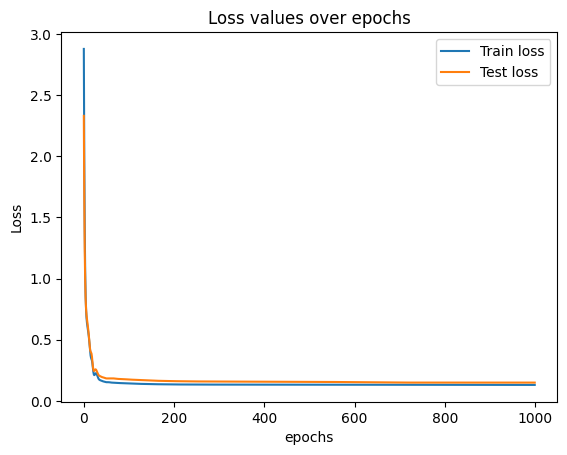

In [117]:
#%% Model instanciation
model = Basic_AE([d_in, d_hid],name="Basic_ae")

learning_rate=1e-1
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
train_loss_history = []
test_loss_history = []
n_epochs = 1000

train_and_eval(model,n_epochs,optimizer,x_train_t,x_test_t)

plt.plot(np.arange(n_epochs), train_loss_history, label='Train loss')
plt.plot(np.arange(n_epochs), test_loss_history, label='Test loss')
plt.title('Loss values over epochs')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<div style="background-color: #5CE65C; border:2px solid #ffb703; border-radius:8px; padding:10px; color:black;">

The loss decreases fastly at the beginning representing that the model learns fastly and that the weights adjust quickly. Then we continue to train even if the train loss was mininized meaning that we start to overfit. Probably due to a learning rate too big.

Plot the evolution of the MSE loss w.r.t. time iterations.

### Q3

Try changing the learning rate (1e-1,1e-2,1e-3,1e-5) and discuss the effect on these plots.

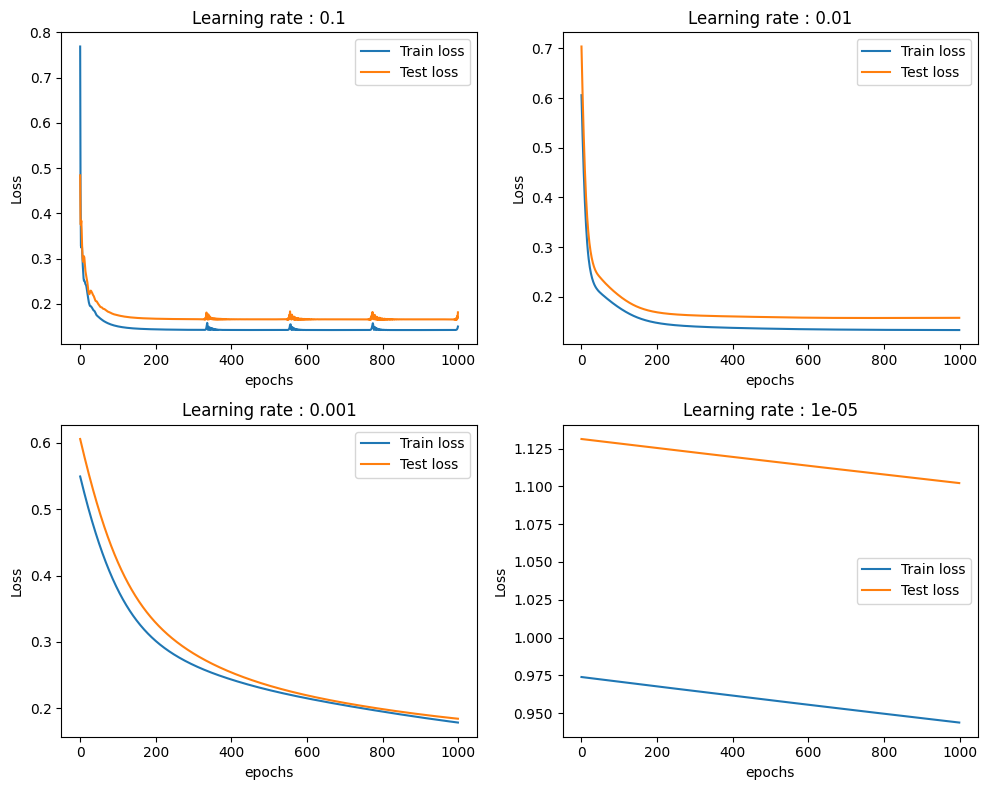

In [122]:
learning_rate = [1e-1, 1e-2, 1e-3, 1e-5]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for idx, lr in enumerate(learning_rate):
    row = idx // 2
    col = idx % 2
    ax = axs[row, col]

    model_lr = Basic_AE([d_in, d_hid],name="Basic_ae")
    optimizer = torch.optim.Adam(model_lr.parameters(), lr=lr)
    train_loss_history = []
    test_loss_history = []
    n_epochs = 1000
    
    train_and_eval(model_lr,n_epochs,optimizer,x_train_t,x_test_t, verbose=False)
    
    #%% Plots
    ax.plot(np.arange(n_epochs), train_loss_history, label='Train loss')
    ax.plot(np.arange(n_epochs), test_loss_history, label='Test loss')
    ax.set_title(f'Learning rate : {lr}')
    ax.set_xlabel("epochs")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

<div style="background-color: #5CE65C; border:2px solid #ffb703; border-radius:8px; padding:10px; color:black;">

We observe that whether we have a high learning rate the model overfits strongly and in the other hand, if the learning rate is too low the model learns too slowly yielding underfit. By using the graph, the best seems to be 0.001 even it we have a slow convergence .

### Q5 

Plot these 2D representations and check that the main geometry of the dataset is preserved.
In order to compute the 2D representation, you should add a `coding` function in the `Basic_AE` class that outputs the `z` (hidden representation) value. We apply `.detach().numpy()` on the obtained value in order to isolate it from the computation graph so that no gradients can be computed on top of that. 


(100, 2)


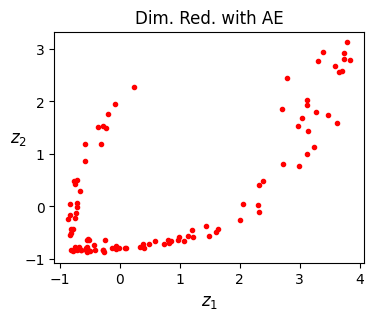

In [125]:
codings_val = model.coding(x_train_t).detach().numpy()

print(codings_val.shape)

fig = plt.figure(figsize=(4,3))
plt.plot(codings_val[:,0], codings_val[:, 1], "r.")
plt.xlabel("$z_1$", fontsize=12)
plt.ylabel("$z_2$", fontsize=12, rotation=0)
plt.title('Dim. Red. with AE')
plt.show()

### Q6

Apply **PCA** to the same dataset and compare the results. (You may use the `sklearn` version of PCA but you will need to install the corresponding python module.)

In [120]:
#%% PCA
from sklearn.decomposition import PCA

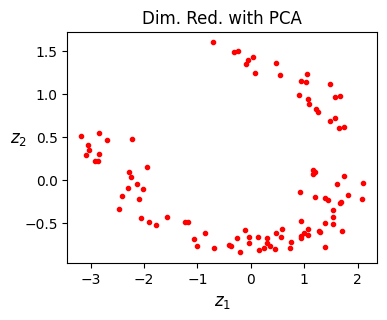

In [124]:
pca = PCA(n_components=2)
X_new = pca.fit_transform(X_train)

fig = plt.figure(figsize=(4,3))
plt.plot(X_new[:,0], X_new[:, 1], "r.")
plt.xlabel("$z_1$", fontsize=12)
plt.ylabel("$z_2$", fontsize=12, rotation=0)
plt.title('Dim. Red. with PCA')
plt.show()

## Concluding remarks

<div style="background-color: #5CE65C; border:2px solid #ffb703; border-radius:8px; padding:10px; color:black;">

PCA performs linear dimensionality reduction, while the autoencoder uses non-linear mappings. Therefore, the autoencoder can model more complex geometries in the data and get a more precise representation.